In [1]:
import os, sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))  # notebooks/ -> 프로젝트 루트
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("src exists:", os.path.isdir(os.path.join(PROJECT_ROOT, "src")))

PROJECT_ROOT: /Users/yunna/Desktop/nutri-cluster
src exists: True


In [2]:
import pandas as pd

features_path = "./data/processed/features_reco.csv"
meta_path = "./data/processed/meta_reco.csv"

X_df = pd.read_csv(features_path)
meta_df = pd.read_csv(meta_path)

print("X_df:", X_df.shape, "meta_df:", meta_df.shape)
assert X_df.shape[0] == meta_df.shape[0], "행 개수(제품 수)가 서로 달라요!"
print(X_df.head(3))
print("dtypes:", X_df.dtypes.value_counts())

X_df: (895, 26) meta_df: (895, 5)
   vitamin_c  vitamin_b  vitamin_d  zinc  magnesium  iron  folate  selenium  \
0          1          1          0     0          0     1       0         0   
1          1          1          0     0          0     1       0         0   
2          1          0          0     0          1     0       0         0   

   probiotics  prebiotics  ...  glucosamine  chondroitin  omega3  coq10  \
0           0           0  ...            0            0       0      0   
1           0           0  ...            0            0       0      0   
2           1           1  ...            0            0       0      0   

   milk_thistle  red_ginseng  l_theanine  melatonin  garcinia  green_tea  
0             0            0           0          0         0          0  
1             0            0           0          0         0          0  
2             0            0           0          0         0          0  

[3 rows x 26 columns]
dtypes: int64    26
Name:

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = X_df.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X_scaled)

print("explained variance ratio:", pca.explained_variance_ratio_)
print("total explained:", pca.explained_variance_ratio_.sum())

explained variance ratio: [0.14877637 0.07733452]
total explained: 0.2261108835377741


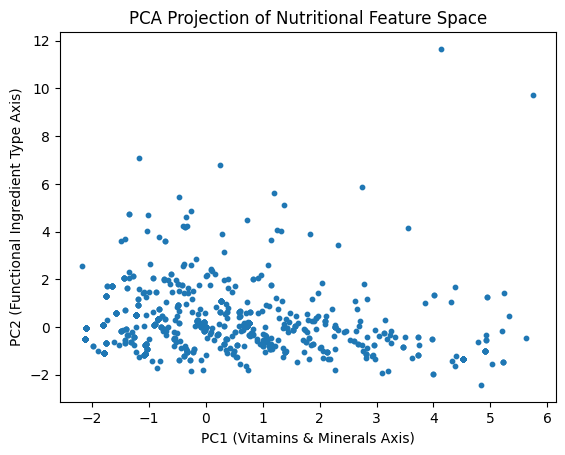

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(Z[:, 0], Z[:, 1], s=10)

plt.xlabel("PC1 (Vitamins & Minerals Axis)")
plt.ylabel("PC2 (Functional Ingredient Type Axis)")

plt.title("PCA Projection of Nutritional Feature Space")
plt.show()

In [5]:
import numpy as np

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_df.columns,
    columns=["PC1_loading", "PC2_loading"]
)

print("=== Top +PC1 ===")
display(loadings["PC1_loading"].sort_values(ascending=False).head(10))

print("=== Top -PC1 ===")
display(loadings["PC1_loading"].sort_values().head(10))

print("=== Top +PC2 ===")
display(loadings["PC2_loading"].sort_values(ascending=False).head(10))

print("=== Top -PC2 ===")
display(loadings["PC2_loading"].sort_values().head(10))

=== Top +PC1 ===


magnesium     0.369150
folate        0.357722
vitamin_d     0.356798
iron          0.345976
vitamin_c     0.345601
zinc          0.340638
calcium       0.320029
vitamin_b     0.170189
probiotics    0.136301
selenium      0.117691
Name: PC1_loading, dtype: float64

=== Top -PC1 ===


red_ginseng   -2.534388e-01
garcinia      -3.841997e-02
omega3        -3.740577e-02
msm           -7.609822e-03
hyaluronic    -6.961888e-03
melatonin     -1.613682e-34
astaxanthin    4.135903e-25
l_theanine     5.507242e-03
prebiotics     8.898231e-03
lutein         1.373278e-02
Name: PC1_loading, dtype: float64

=== Top +PC2 ===


collagen       0.459096
glucosamine    0.397715
chondroitin    0.272590
garcinia       0.272438
hyaluronic     0.261571
msm            0.238160
green_tea      0.231726
prebiotics     0.180535
probiotics     0.123923
magnesium      0.083130
Name: PC2_loading, dtype: float64

=== Top -PC2 ===


red_ginseng    -0.317218
vitamin_b      -0.297305
folate         -0.162091
milk_thistle   -0.106268
iron           -0.102787
zinc           -0.063273
lutein         -0.047208
calcium        -0.041703
coq10          -0.041293
vitamin_d      -0.023417
Name: PC2_loading, dtype: float64

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_for_cluster = X_scaled  # PCA 말고, 원본 표준화 데이터로 클러스터링

scores = {}
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_for_cluster)
    score = silhouette_score(X_for_cluster, labels)
    scores[k] = score
    print(f"k={k}, silhouette score={score:.3f}")

k=2, silhouette score=0.223
k=3, silhouette score=0.218
k=4, silhouette score=0.208
k=5, silhouette score=0.215
k=6, silhouette score=0.175


In [7]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_for_cluster)

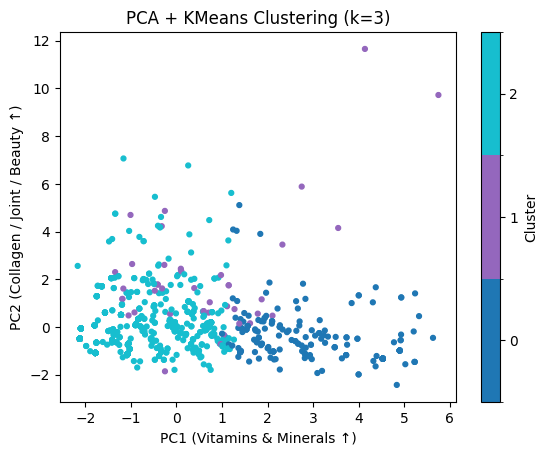

In [8]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

cmap = plt.get_cmap("tab10")
bounds = np.arange(-0.5, k + 0.5, 1)  # [-0.5, 0.5, 1.5, 2.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure()
sc = plt.scatter(Z[:, 0], Z[:, 1], c=labels, s=12, cmap=cmap, norm=norm)
plt.xlabel("PC1 (Vitamins & Minerals ↑)")
plt.ylabel("PC2 (Collagen / Joint / Beauty ↑)")
plt.title("PCA + KMeans Clustering (k=3)")
cbar = plt.colorbar(sc, ticks=[0, 1, 2])
cbar.set_label("Cluster")
plt.show()

In [9]:
from IPython.display import display

for c in range(k):
    idx = labels == c
    mean_features = X_df[idx].mean().sort_values(ascending=False)
    print(f"\n=== Cluster {c} 대표 성분 (top10) ===")
    display(mean_features.head(10))


=== Cluster 0 대표 성분 (top10) ===


magnesium     0.871658
vitamin_c     0.844920
vitamin_b     0.823529
calcium       0.743316
zinc          0.711230
vitamin_d     0.641711
iron          0.636364
folate        0.577540
probiotics    0.315508
prebiotics    0.235294
dtype: float64


=== Cluster 1 대표 성분 (top10) ===


green_tea     0.953488
magnesium     0.581395
vitamin_b     0.534884
vitamin_c     0.511628
calcium       0.348837
garcinia      0.325581
prebiotics    0.279070
zinc          0.232558
collagen      0.186047
iron          0.162791
dtype: float64


=== Cluster 2 대표 성분 (top10) ===


red_ginseng    0.443609
vitamin_b      0.422556
vitamin_c      0.261654
magnesium      0.254135
prebiotics     0.215038
calcium        0.187970
probiotics     0.117293
zinc           0.102256
iron           0.081203
vitamin_d      0.069173
dtype: float64

In [10]:
result = meta_df.copy()
result["cluster"] = labels
result["PC1"] = Z[:, 0]
result["PC2"] = Z[:, 1]

for c in range(k):
    print(f"\n=== Cluster {c} 대표 제품 ===")
    sub = result[result["cluster"] == c].copy()
    sub["dist"] = (sub["PC1"]**2 + sub["PC2"]**2) ** 0.5
    cols = [col for col in ["PRDLST_NM", "BSSH_NM"] if col in sub.columns]
    display(sub.sort_values("dist")[cols + ["PC1", "PC2"]].head(5))


=== Cluster 0 대표 제품 ===


,PRDLST_NM,BSSH_NM,PC1,PC2
614,프로바이오베베,(주)비피도,1.001151,-0.283549
266,진마미모미철분,(주)유유헬스케어,1.061785,-0.390918
130,옵티마엽산,주)팜크로스,1.082799,-0.628081
661,얼라이브10프로바이오틱스300,(주)유유헬스케어,1.296663,0.385421
593,정상적인 면역기능에 필요한 프로그램,(주)유유헬스케어,1.358190,-0.042407



=== Cluster 1 대표 제품 ===


,PRDLST_NM,BSSH_NM,PC1,PC2
283,EBM 비움 S,경성제약주식회사,-0.139597,0.541325
644,번업12,주식회사한미양행,0.598386,0.658288
804,와일드망고다이어트,주식회사한미양행,0.598386,0.658288
239,홍슬림다이어트,(주)일화,0.824652,-0.360100
303,폴리맥스프리미엄,주식회사한미양행,0.709980,0.599257



=== Cluster 2 대표 제품 ===


,PRDLST_NM,BSSH_NM,PC1,PC2
689,더팜 썬디드롭스 1000IU,(주)팜텍코리아,0.006601,0.014876
691,썬디드롭스 600IU,(주)팜텍코리아,0.006601,0.014876
690,더팜 썬디드롭스 400IU,(주)팜텍코리아,0.006601,0.014876
815,아이누리 비타D 400IU,(주)팜텍코리아,0.006601,0.014876
725,닥터썬디드롭스 400IU,(주)팜텍코리아,0.006601,0.014876


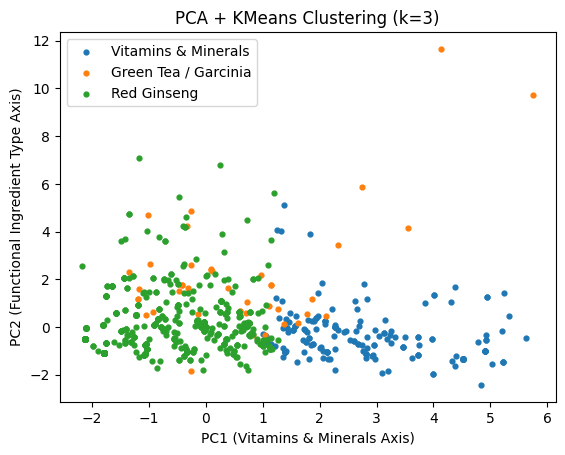

In [14]:
names = {0:"Vitamins & Minerals", 1:"Green Tea / Garcinia", 2:"Red Ginseng"}

plt.figure()
for c in range(k):
    idx = labels == c
    plt.scatter(Z[idx,0], Z[idx,1], s=12, label=names[c])

plt.xlabel("PC1 (Vitamins & Minerals Axis)")
plt.ylabel("PC2 (Functional Ingredient Type Axis)")

plt.title("PCA + KMeans Clustering (k=3)")
plt.legend()
plt.show()

In [12]:
from src.preprocess import recommend_by_need
features_df = X_df
# 이미 위에서 불러온 features_df, meta_df 그대로 사용
recommend_by_need(features_df, meta_df, need="immune", top_n=10)

,PRDLST_NM,BSSH_NM,PRMS_DT,PRDLST_REPORT_NO,LCNS_NO,score
766,헬스트리 포맨,(주)유유헬스케어,2015-05-27,20040015107636,20040015107,10
228,홍삼멀티비타민&미네랄,(주)유유헬스케어,2010-08-02,20040015107388,20040015107,9
774,웰키커(well-kicker) 멀티비타민앤미네랄,디에이치팜(주),2015-06-10,20040015102156,20040015102,9
317,포세이돈포맨,(주)유유헬스케어,2011-06-15,20040015107428,20040015107,9
318,헤라실버포우먼,(주)유유헬스케어,2011-06-15,20040015107427,20040015107,9
534,그린키즈츄어블아연,주)팜크로스,2013-08-26,20040015110457,20040015110,9
526,알파브레인,주식회사한미양행,2013-08-08,20040015083632,20040015083,9
311,제우스실버포맨,(주)유유헬스케어,2011-06-02,20040015107426,20040015107,9
812,그린키즈츄어블아연딸기맛,주)팜크로스,2015-09-16,20040015110567,20040015110,9
695,프리미엄큐 비타민무기질,디에이치팜(주),2014-11-25,20040015102146,20040015102,9


In [13]:
top30 = recommend_by_need(features_df, meta_df, need="immune", top_n=30)

top30 = top30.merge(
    result[["PRDLST_NM", "cluster"]],
    on="PRDLST_NM",
    how="left"
)

top30["cluster"].value_counts()

cluster
0    26
1     4
Name: count, dtype: int64